# 看着机械臂从随机动作变成正确动作：DiT / Flow Matching 可视化教程

这个 Notebook 使用一个可以实时渲染的二维双关节机械臂仿真。模型看到的 observation 不再是抽象数字，而是：

```text
RGB 仿真图像：当前机械臂 + 绿色目标点
proprioception：当前两个关节角
```

DiT 从一段随机关节动作开始，经过四次 Euler 更新，生成未来 8 个关节位置。每个 flow 阶段都会重新渲染成 8 帧仿真图像，因此可以直接看到动作怎样逐渐伸向绿色目标。

> 这是教学用 Tiny DiT：RGB 图像经过小型 CNN 变成 image context token，当前关节状态变成 state context token，noisy action 经过 action encoder 变成 action tokens。Transformer 对 observation 做 cross-attention，然后输出 velocity。暂时不加入 TTT。


In [ ]:
# 数学函数：使用 pi、log 等。
import math

# NumPy：只用于绘图和 loss 移动平均。
import numpy as np

# PyTorch：渲染批量仿真图像、建立 DiT、训练和推理。
import torch
from torch import nn
import torch.nn.functional as F

# Matplotlib：显示 RGB observation、动作 rollout 和曲线。
import matplotlib.pyplot as plt

# 固定随机种子，使每次运行的结果可以复现。
torch.manual_seed(7)
np.random.seed(7)

# 提高 Notebook 图片清晰度。
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = False

# 优先使用 GPU；没有 GPU 时也可以在 CPU 上运行。
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 打印运行环境。
print('device =', device)
print('torch version =', torch.__version__)


## 1. 二维双关节机械臂仿真

机械臂有两个旋转关节：

```text
joint action = [shoulder_angle, elbow_angle]
action chunk shape = [batch, 8, 2]
```

RGB 图像中的颜色：

- 深色圆点：底座和关节；
- 蓝色：第一段机械臂；
- 橙色：第二段机械臂；
- 绿色圆点：需要到达的目标。


In [ ]:
# RGB 仿真图像大小为 48x48。
IMAGE_SIZE = 48

# 一个 action chunk 包含未来 8 个关节位置。
HORIZON = 8

# 每个动作包含肩关节和肘关节两个角度。
ACTION_DIM = 2

# 两段机械臂的长度。
LINK_1 = 0.58
LINK_2 = 0.42

# 机械臂底座固定在工作台下方中央。
ARM_BASE = torch.tensor([0.0, -0.72], dtype=torch.float32)

def forward_kinematics(joint_angles: torch.Tensor):
    """把两个关节角转换成第一关节和末端执行器的二维坐标。"""

    # shoulder 是第一关节相对 x 轴的角度。
    shoulder = joint_angles[..., 0]

    # elbow 是第二段机械臂相对第一段的角度。
    elbow = joint_angles[..., 1]

    # 将底座坐标移动到和输入张量相同的 device。
    base = ARM_BASE.to(joint_angles.device)

    # 第一关节位置：base + 第一段机械臂向量。
    joint_1 = torch.stack((
        base[0] + LINK_1 * torch.cos(shoulder),
        base[1] + LINK_1 * torch.sin(shoulder),
    ), dim=-1)

    # 第二段的绝对方向是 shoulder + elbow。
    second_link_angle = shoulder + elbow

    # 末端执行器位置：joint_1 + 第二段机械臂向量。
    end_effector = joint_1 + torch.stack((
        LINK_2 * torch.cos(second_link_angle),
        LINK_2 * torch.sin(second_link_angle),
    ), dim=-1)

    # 返回第一关节和末端执行器坐标。
    return joint_1, end_effector

def point_to_segment_distance(pixel_grid, segment_start, segment_end):
    """计算每个图像像素到一条机械臂线段的最短距离。"""

    # 线段方向向量，shape 可以广播到整张图像。
    segment = segment_end - segment_start

    # 计算像素在线段方向上的投影比例。
    projection = ((pixel_grid - segment_start) * segment).sum(dim=-1, keepdim=True)
    projection = projection / segment.square().sum(dim=-1, keepdim=True).clamp_min(1e-8)

    # 将投影限制在线段内部。
    projection = projection.clamp(0.0, 1.0)

    # 得到每个像素在线段上的最近点。
    closest_point = segment_start + projection * segment

    # 返回像素到最近点的欧氏距离。
    return (pixel_grid - closest_point).square().sum(dim=-1).sqrt()

def render_robot_images(joint_angles: torch.Tensor, target_xy: torch.Tensor) -> torch.Tensor:
    """批量渲染机械臂 RGB 图像，返回 [B,3,48,48]。"""

    # batch size 是需要同时渲染的机械臂数量。
    batch_size = joint_angles.shape[0]

    # 创建工作台 x 坐标；范围稍大于机械臂可达空间。
    x_coordinates = torch.linspace(-1.1, 1.1, IMAGE_SIZE, device=joint_angles.device)

    # 图像第一行对应较大的 y，因此从 1.1 递减到 -1.1。
    y_coordinates = torch.linspace(1.1, -1.1, IMAGE_SIZE, device=joint_angles.device)

    # 将 x/y 坐标组成每个像素的二维世界坐标 [1,H,W,2]。
    grid_y, grid_x = torch.meshgrid(y_coordinates, x_coordinates, indexing='ij')
    pixel_grid = torch.stack((grid_x, grid_y), dim=-1)[None, :, :, :]

    # 根据关节角计算第一关节和末端执行器位置。
    joint_1, end_effector = forward_kinematics(joint_angles)

    # 将底座扩展成 [B,1,1,2]，用于像素距离计算。
    base = ARM_BASE.to(joint_angles.device).view(1, 1, 1, 2).expand(batch_size, -1, -1, -1)

    # 把关键点都变成 [B,1,1,2]。
    joint_1_grid = joint_1[:, None, None, :]
    end_effector_grid = end_effector[:, None, None, :]
    target_grid = target_xy[:, None, None, :]

    # 计算每个像素到两段机械臂的距离。
    distance_link_1 = point_to_segment_distance(pixel_grid, base, joint_1_grid)
    distance_link_2 = point_to_segment_distance(pixel_grid, joint_1_grid, end_effector_grid)

    # 计算每个像素到底座、关节、末端和目标的距离。
    distance_base = (pixel_grid - base).square().sum(dim=-1).sqrt()
    distance_joint_1 = (pixel_grid - joint_1_grid).square().sum(dim=-1).sqrt()
    distance_end_effector = (pixel_grid - end_effector_grid).square().sum(dim=-1).sqrt()
    distance_target = (pixel_grid - target_grid).square().sum(dim=-1).sqrt()

    # 用浅灰色初始化 RGB 背景。
    image = torch.full(
        (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE), 0.94, device=joint_angles.device
    )

    # 定义绘图辅助函数：在 mask 区域写入给定 RGB 颜色。
    def paint(current_image, mask, color):
        color_tensor = torch.tensor(color, device=current_image.device).view(1, 3, 1, 1)
        return torch.where(mask[:, None, :, :], color_tensor, current_image)

    # 第一段机械臂画成蓝色。
    image = paint(image, distance_link_1 < 0.055, [0.18, 0.42, 0.85])

    # 第二段机械臂画成橙色。
    image = paint(image, distance_link_2 < 0.050, [0.95, 0.48, 0.12])

    # 底座和第一关节画成深色圆点。
    image = paint(image, distance_base < 0.075, [0.12, 0.12, 0.15])
    image = paint(image, distance_joint_1 < 0.065, [0.12, 0.12, 0.15])

    # 末端执行器画成红色。
    image = paint(image, distance_end_effector < 0.060, [0.88, 0.12, 0.18])

    # 目标最后绘制成绿色，避免被机械臂遮住。
    image = paint(image, distance_target < 0.075, [0.10, 0.78, 0.25])

    # 返回范围为 [0,1] 的 RGB 图像。
    return image

def make_expert_joint_actions(current_joints, target_joints):
    """将当前关节角平滑插值到目标关节角，得到 8 步专家动作。"""

    # 创建从 1/8 到 1 的动作进度 [1,8,1]。
    progress = torch.linspace(1.0 / HORIZON, 1.0, HORIZON, device=current_joints.device)
    progress = progress.view(1, HORIZON, 1)

    # smoothstep 让动作开始和结束更平滑。
    smooth_progress = 3.0 * progress.square() - 2.0 * progress.pow(3)

    # 对两个关节角同时插值。
    return current_joints[:, None, :] * (1.0 - smooth_progress) + target_joints[:, None, :] * smooth_progress

def show_rgb(ax, image, title):
    """显示单张 [3,H,W] RGB 仿真图像。"""

    # 将通道从 [3,H,W] 调整成 Matplotlib 使用的 [H,W,3]。
    image_for_plot = image.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0)

    # 显示图像并隐藏像素坐标。
    ax.imshow(image_for_plot)
    ax.set_title(title)
    ax.axis('off')

def rollout_image_strip(action_chunk, target_xy):
    """把 8 个关节动作渲染成一条连续的 RGB 图像带。"""

    # action_chunk 是 [8,2]，每一行都是一帧机械臂关节角。
    number_of_frames = action_chunk.shape[0]

    # 将同一个绿色目标复制给 8 帧。
    repeated_target = target_xy[None, :].expand(number_of_frames, -1)

    # 批量渲染 8 张 RGB 图像 [8,3,H,W]。
    frames = render_robot_images(action_chunk, repeated_target)

    # 沿图像宽度拼接，得到 [3,H,8W] 的图像带。
    strip = torch.cat([frame for frame in frames], dim=2)

    # 调整成 [H,8W,3] 供 Matplotlib 显示。
    return strip.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0)

def show_rollout_row(ax, action_chunk, target_xy, title):
    """在一行中显示一个完整的 8 帧机械臂动作 chunk。"""

    # 渲染并显示 8 帧图像带。
    ax.imshow(rollout_image_strip(action_chunk, target_xy))
    ax.set_title(title, loc='left')
    ax.axis('off')

    # 在图像带下方标出 action 1 到 action 8。
    for frame_index in range(HORIZON):
        x_position = (frame_index + 0.5) * IMAGE_SIZE
        ax.text(x_position, IMAGE_SIZE + 3, str(frame_index + 1), ha='center', va='top', fontsize=8)


### 生成一个具体仿真场景

绿色目标由一组目标关节角的末端位置产生，因此它一定在机械臂可达范围内。模型不会看到目标关节角，只会看到 RGB 图像中的绿色点。


In [ ]:
# 当前机械臂关节角，单位是弧度。
demo_current_joints = torch.tensor([[2.25, -1.10]], device=device)

# 目标关节角只用于生成可达绿色目标和专家动作，不会直接输入模型。
demo_target_joints = torch.tensor([[0.75, 1.05]], device=device)

# 通过目标关节角的正运动学得到绿色目标坐标。
_, demo_target_xy = forward_kinematics(demo_target_joints)

# 渲染当前机械臂和绿色目标，得到模型真正看到的 RGB observation。
demo_rgb = render_robot_images(demo_current_joints, demo_target_xy)

# 构造当前关节角到目标关节角的 8 步专家动作。
demo_expert_actions = make_expert_joint_actions(demo_current_joints, demo_target_joints)

# 左侧显示单张 RGB observation，右侧显示专家动作的 8 帧仿真 rollout。
fig, axes = plt.subplots(2, 1, figsize=(14, 5), gridspec_kw={'height_ratios': [1.2, 1.0]})
show_rgb(axes[0], demo_rgb[0], 'RGB observation: current arm + green target')
show_rollout_row(axes[1], demo_expert_actions[0], demo_target_xy[0], 'Expert action chunk: 8 future robot frames')
plt.tight_layout()
plt.show()

# 打印模型输入和动作输出的基本 shape。
print('RGB observation :', tuple(demo_rgb.shape), '= [B,3,48,48]')
print('joint state     :', tuple(demo_current_joints.shape), '= [B,2]')
print('action chunk    :', tuple(demo_expert_actions.shape), '= [B,8,2]')


## 2. Flow matching 训练样本也渲染成机械臂图像

对完整的 8 步专家关节动作 `a` 加入随机动作 `epsilon`：

```text
x_tau = (1-tau) * epsilon + tau * a
target_velocity = a - epsilon
```

`tau=0` 是随机机械臂动作，`tau=1` 是专家动作。下面直接把它们渲染成仿真 rollout。


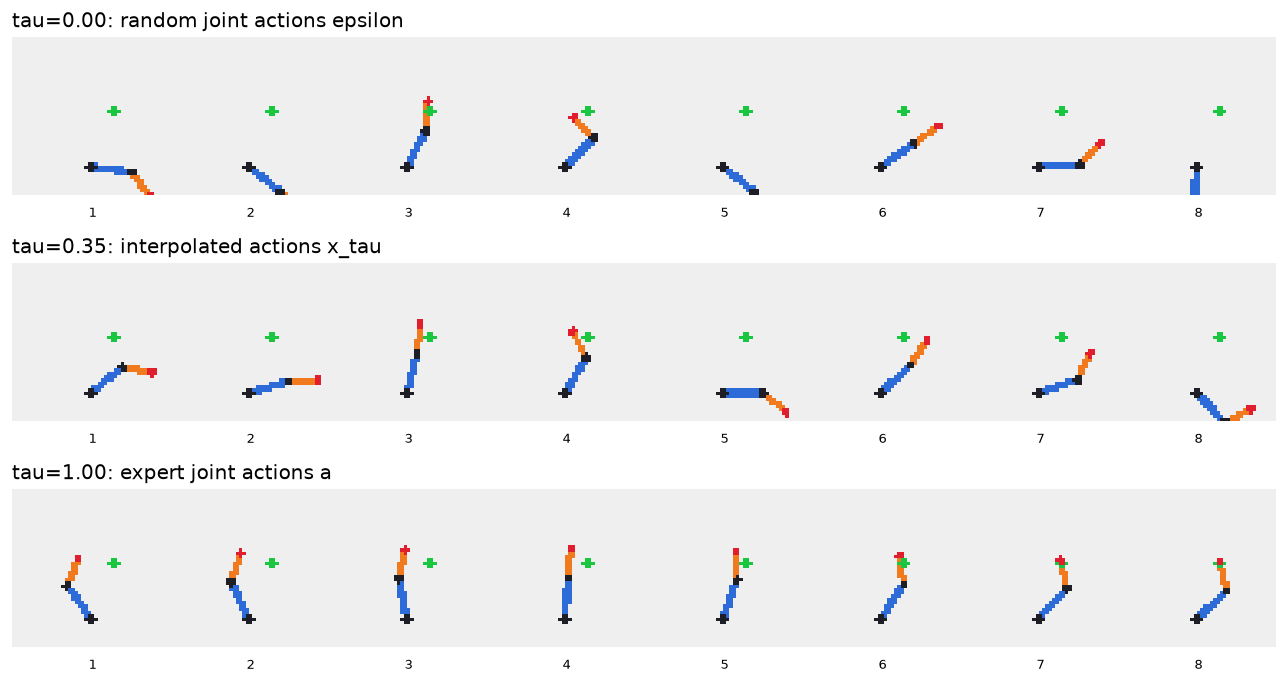

epsilon shape        = (1, 8, 2)
x_tau shape          = (1, 8, 2)
target velocity shape= (1, 8, 2)


In [49]:
# 固定随机种子，生成可复现的随机关节动作 epsilon。
torch.manual_seed(11)
demo_noise_actions = torch.randn_like(demo_expert_actions) * 1.10

# 手工选择 tau=0.35；真实训练时每个样本会独立随机采样。
demo_tau = torch.tensor([0.35], device=device)

# 将 tau 扩展为 [B,1,1]，以便和 [B,8,2] 动作广播。
tau_for_actions = demo_tau[:, None, None]

# 构造噪声动作和专家动作之间的中间状态 x_tau。
demo_x_tau = (1.0 - tau_for_actions) * demo_noise_actions
demo_x_tau = demo_x_tau + tau_for_actions * demo_expert_actions

# 直线路径的 velocity 标签是 a-epsilon。
demo_target_velocity = demo_expert_actions - demo_noise_actions

# 分别渲染纯噪声、中间动作和专家动作。
fig, axes = plt.subplots(3, 1, figsize=(15, 5.8))
show_rollout_row(axes[0], demo_noise_actions[0], demo_target_xy[0], 'tau=0.00: random joint actions epsilon')
show_rollout_row(axes[1], demo_x_tau[0], demo_target_xy[0], 'tau=0.35: interpolated actions x_tau')
show_rollout_row(axes[2], demo_expert_actions[0], demo_target_xy[0], 'tau=1.00: expert joint actions a')
plt.tight_layout()
plt.show()

# 再次确认所有动作相关张量都是 [B,8,2]。
print('epsilon shape        =', tuple(demo_noise_actions.shape))
print('x_tau shape          =', tuple(demo_x_tau.shape))
print('target velocity shape=', tuple(demo_target_velocity.shape))


## 3. 图像条件 Tiny DiT

模型的数据流是：

```text
RGB image [B,3,48,48] -> CNN -> image context token [B,1,64]
joint state [B,2]      -> MLP -> state context token [B,1,64]
current actions [B,8,2] -> action encoder -> action tokens [B,8,64]
tau [B] -> time encoder -> 加到 8 个 action tokens

action tokens --Transformer/cross-attention--> hidden --decoder--> velocity [B,8,2]
```

第一次 Euler step 的 `current actions` 就是随机噪声。`action_encoder` 只是把当前二维关节动作投影成 64 维 token。


In [48]:
def sinusoidal_time_embedding(tau: torch.Tensor, hidden_dim: int) -> torch.Tensor:
    """将标量 tau 转成 Transformer 使用的正弦时间特征。"""

    # 一半通道使用 sin，另一半通道使用 cos。
    half_dim = hidden_dim // 2

    # 创建不同尺度的频率。
    frequency_index = torch.arange(half_dim, device=tau.device, dtype=torch.float32)
    frequencies = torch.exp(-math.log(10_000.0) * frequency_index / max(half_dim - 1, 1))

    # 每个 tau 与所有频率相乘，得到 [B,half_dim] 角度。
    angles = 2.0 * math.pi * tau[:, None] * frequencies[None, :]

    # 拼接 sin/cos，得到 [B,hidden_dim]。
    return torch.cat((angles.sin(), angles.cos()), dim=-1)

class TinyVisualDiT(nn.Module):
    """RGB 图像 + 关节状态条件下的极简 DiT action head。"""

    def __init__(self, hidden_dim=64, num_layers=2, num_heads=4):
        # 初始化 PyTorch Module。
        super().__init__()

        # 保存 hidden dimension，时间编码时使用。
        self.hidden_dim = hidden_dim

        # CNN 将 48x48 RGB observation 压缩成一个 64 维 image token。
        # 注意：这里保留 6x6 空间网格后再用 Linear 投影。
        # 如果直接做全局平均池化，绿色目标点在哪儿的信息会被严重削弱。
        self.image_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2),
            nn.SiLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, hidden_dim),
        )

        # 当前两个关节角通过 MLP 变成一个 state context token。
        self.state_encoder = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # action encoder 对 8 个当前关节动作分别执行 2 -> 64 投影。
        self.action_encoder = nn.Sequential(
            nn.Linear(ACTION_DIM, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # time encoder 对正弦时间特征做可学习映射。
        self.time_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # 八个未来动作位置各有一个 learned position embedding。
        self.action_position_embedding = nn.Parameter(torch.randn(HORIZON, hidden_dim) * 0.02)

        # 每个 block 包含 action self-attention、observation cross-attention 和 FFN。
        self.transformer_blocks = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 3,
                dropout=0.0,
                batch_first=True,
                norm_first=True,
                activation='gelu',
            )
            for _ in range(num_layers)
        ])

        # 输出 velocity 之前的归一化。
        self.final_norm = nn.LayerNorm(hidden_dim)

        # action decoder 将 64 维 hidden token 还原成二维关节 velocity。
        self.action_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, ACTION_DIM),
        )

    def forward(self, rgb_image, joint_state, current_actions, tau, return_debug=False):
        """给定 observation、当前动作状态和 tau，预测动作 velocity。"""

        # CNN 把 RGB 图像变成 [B,64] image token。
        image_token = self.image_encoder(rgb_image)

        # MLP 把当前关节状态变成 [B,64] state token。
        state_token = self.state_encoder(joint_state)

        # 两个 context token 组成 [B,2,64] observation context。
        context_tokens = torch.stack((image_token, state_token), dim=1)

        # 当前动作第一次是随机噪声；action encoder 将 [B,8,2] 投影成 [B,8,64]。
        action_tokens = self.action_encoder(current_actions)

        # 加入动作 chunk 内部的位置顺序。
        action_tokens = action_tokens + self.action_position_embedding[None, :, :]

        # 将 tau 编码为 [B,64] flow-time token。
        time_token = self.time_encoder(sinusoidal_time_embedding(tau, self.hidden_dim))

        # 同一个 flow time 条件加到所有 8 个 action tokens。
        hidden = action_tokens + time_token[:, None, :]

        # 保存中间 token，仅用于教学可视化。
        debug_states = [('action encoder + time', hidden)]

        # 依次通过两个 DiT-like Transformer block。
        for block_index, block in enumerate(self.transformer_blocks):
            # tgt 做 action self-attention；memory 提供 image/state cross-attention。
            hidden = block(tgt=hidden, memory=context_tokens)

            # 保存每一层输出，后面画 token 热力图。
            debug_states.append((f'after transformer block {block_index + 1}', hidden))

        # 解码出 [B,8,2] predicted velocity。
        predicted_velocity = self.action_decoder(self.final_norm(hidden))

        # 教学模式额外返回 context 和中间 hidden。
        if return_debug:
            return predicted_velocity, context_tokens, debug_states

        # 正常模式只返回 velocity。
        return predicted_velocity

# 创建图像条件 Tiny DiT，并移动到对应 device。
model = TinyVisualDiT().to(device)

# 打印模型规模。
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'TinyVisualDiT parameters = {parameter_count:,}')


TinyVisualDiT parameters = 310,818


### 未训练模型的数据 shape

这里先不关心预测是否正确，只看 RGB 图像、关节状态、随机动作分别怎样进入模型。


RGB image                  : (1, 3, 48, 48)
current joint state        : (1, 2)
current random actions     : (1, 8, 2)
image + state context      : (1, 2, 64)
action encoder + time      : (1, 8, 64)
after transformer block 1  : (1, 8, 64)
after transformer block 2  : (1, 8, 64)
decoded velocity          : (1, 8, 2)


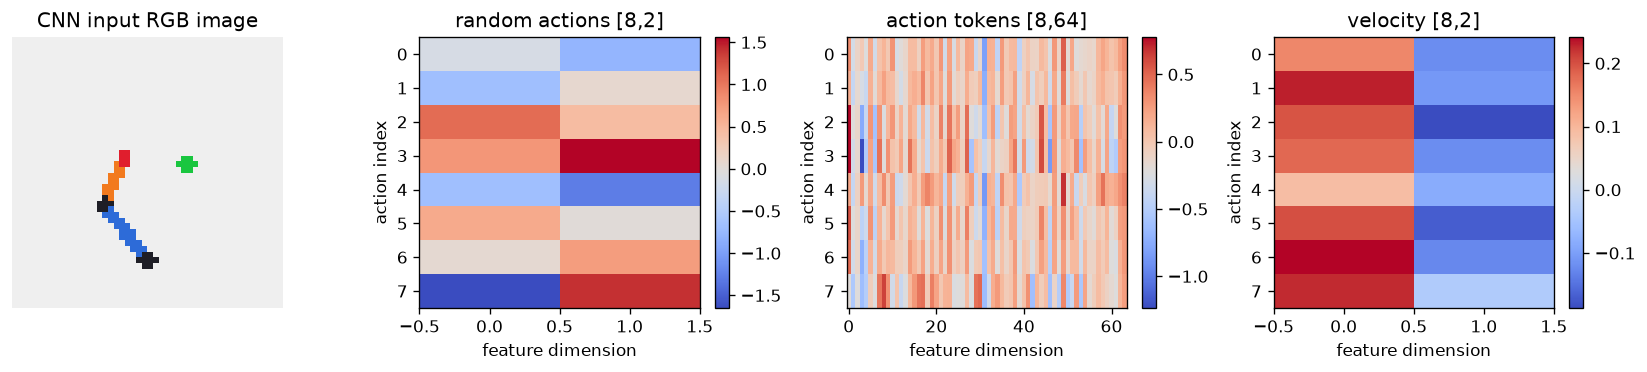

In [42]:
# 关闭梯度，因为这里只检查前向数据流。
with torch.no_grad():
    # tau=0 对应纯噪声动作端。
    zero_tau = torch.zeros(1, device=device)

    # 把 RGB observation、当前关节、随机动作和 tau 输入模型。
    untrained_velocity, context_tokens, debug_states = model(
        demo_rgb, demo_current_joints, demo_noise_actions, zero_tau, return_debug=True
    )

# 打印每条输入路径的 shape。
print('RGB image                  :', tuple(demo_rgb.shape))
print('current joint state        :', tuple(demo_current_joints.shape))
print('current random actions     :', tuple(demo_noise_actions.shape))
print('image + state context      :', tuple(context_tokens.shape))
for state_name, state_tensor in debug_states:
    print(f'{state_name:27s}:', tuple(state_tensor.shape))
print('decoded velocity          :', tuple(untrained_velocity.shape))

# 第一幅显示真正输入 CNN 的 RGB observation。
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
show_rgb(axes[0], demo_rgb[0], 'CNN input RGB image')

# 后三幅用热力图显示动作投影和 velocity。
heatmaps = [demo_noise_actions[0], debug_states[0][1][0], untrained_velocity[0]]
heatmap_titles = ['random actions [8,2]', 'action tokens [8,64]', 'velocity [8,2]']
for ax, heatmap, title in zip(axes[1:], heatmaps, heatmap_titles):
    image = ax.imshow(heatmap.detach().cpu(), aspect='auto', cmap='coolwarm')
    ax.set_title(title)
    ax.set_xlabel('feature dimension')
    ax.set_ylabel('action index')
    fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## 4. 用随机机械臂场景训练 DiT

每个 batch 都会随机生成：当前机械臂姿态、一个可达绿色目标、RGB observation、专家关节动作、动作噪声和随机 `tau`。模型只能从图像与当前关节状态判断目标动作。


step=   1  velocity_loss=0.091636
step= 225  velocity_loss=0.090988
step= 450  velocity_loss=0.092205
step= 675  velocity_loss=0.072852
step= 900  velocity_loss=0.063190
step=1125  velocity_loss=0.088124
step=1350  velocity_loss=0.065942
step=1575  velocity_loss=0.066222
step=1800  velocity_loss=0.055518
step=2025  velocity_loss=0.076935
step=2250  velocity_loss=0.078190
step=2475  velocity_loss=0.054027
step=2700  velocity_loss=0.044154
step=2925  velocity_loss=0.051682
step=3150  velocity_loss=0.048479
step=3375  velocity_loss=0.055750
step=3600  velocity_loss=0.047003
step=3825  velocity_loss=0.056484
step=4050  velocity_loss=0.055213
step=4275  velocity_loss=0.077201
step=4500  velocity_loss=0.035728
step=4725  velocity_loss=0.043830
step=4950  velocity_loss=0.050338
step=5175  velocity_loss=0.057505
step=5400  velocity_loss=0.076743
step=5625  velocity_loss=0.055021
step=5850  velocity_loss=0.043788
step=6075  velocity_loss=0.054051
step=6300  velocity_loss=0.035634
step=6525  vel

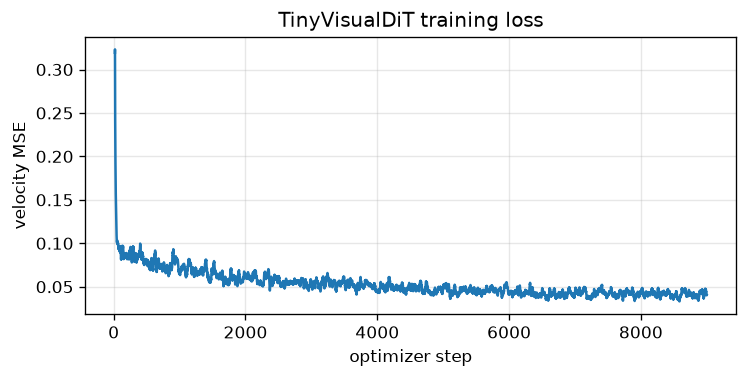

In [46]:
def sample_robot_batch(batch_size: int):
    """生成一批随机机械臂仿真场景及其专家动作。"""

    # 当前肩关节角从较大的可用范围随机采样。
    current_shoulder = torch.rand(batch_size, 1, device=device) * 2.3 + 0.25

    # 当前肘关节角从 [-1.4,1.4] 采样。
    current_elbow = torch.rand(batch_size, 1, device=device) * 2.8 - 1.4

    # 拼成当前 proprioception [B,2]。
    current_joints = torch.cat((current_shoulder, current_elbow), dim=-1)

    # 独立采样目标肩关节和目标肘关节。
    # 目标肘关节固定在正角度分支，避免同一个末端目标对应两套 IK 解。
    # 否则图像只给目标点时，模型无法猜测教师选择的是 elbow-up 还是 elbow-down。
    target_shoulder = torch.rand(batch_size, 1, device=device) * 2.3 + 0.25
    target_elbow = torch.rand(batch_size, 1, device=device) * 1.2 + 0.2
    target_joints = torch.cat((target_shoulder, target_elbow), dim=-1)

    # 目标关节角只用于产生一个一定可达的绿色目标位置。
    _, target_xy = forward_kinematics(target_joints)

    # 渲染模型真正看到的 RGB observation。
    rgb_image = render_robot_images(current_joints, target_xy)

    # 生成当前姿态到目标姿态的 8 步专家关节动作。
    expert_actions = make_expert_joint_actions(current_joints, target_joints)

    # 返回训练与可视化需要的场景信息。
    return rgb_image, current_joints, target_xy, expert_actions

def sample_training_tau(batch_size: int):
    """为 batch 中每个场景独立采样 flow time。"""

    # 当前仓库 DiT 基线使用 Beta(1.5,1.0)。
    alpha = torch.tensor(1.5, device=device)
    beta = torch.tensor(1.0, device=device)

    # 0.999 避免 tau 恰好等于 1。
    return 0.999 * torch.distributions.Beta(alpha, beta).sample((batch_size,))

# 教学模型训练 900 个 optimizer step。
TRAIN_STEPS = 9000

# 每步使用 128 个不同的仿真场景。
BATCH_SIZE = 128

# AdamW 更新 CNN、action encoder、Transformer 和 decoder。
optimizer = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-6)

# 保存 loss 供后面绘图。
training_losses = []

# 切换到训练模式。
model.train()

# 开始 flow-matching 训练。
for training_step in range(1, TRAIN_STEPS + 1):
    # 随机生成 RGB observation、当前关节和专家动作。
    rgb_image, current_joints, target_xy, expert_actions = sample_robot_batch(BATCH_SIZE)

    # 生成与专家动作同形状的随机关节动作 epsilon。
    epsilon = torch.randn_like(expert_actions) * 1.10

    # 每个场景独立随机采样 tau。
    tau = sample_training_tau(BATCH_SIZE)

    # 扩展 tau 维度，使其可以与 [B,8,2] 动作广播。
    tau_for_actions = tau[:, None, None]

    # 构造 flow path 上的 noisy action x_tau。
    x_tau = (1.0 - tau_for_actions) * epsilon + tau_for_actions * expert_actions

    # 直线 flow path 的解析 velocity 标签。
    target_velocity = expert_actions - epsilon

    # DiT 根据图像、当前状态、x_tau 和 tau 预测 velocity。
    predicted_velocity = model(rgb_image, current_joints, x_tau, tau)

    # velocity flow-matching MSE。
    loss = F.mse_loss(predicted_velocity, target_velocity)

    # 清除上一次梯度。
    optimizer.zero_grad(set_to_none=True)

    # 反向传播到整个 Tiny DiT。
    loss.backward()

    # 裁剪过大的梯度。
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # 更新模型参数。
    optimizer.step()

    # 保存 loss 标量。
    training_losses.append(float(loss.detach()))

    # 定期打印训练状态。
    if training_step == 1 or training_step % 225 == 0:
        print(f'step={training_step:4d}  velocity_loss={training_losses[-1]:.6f}')

# 训练完成后切换到推理模式。
model.eval()

# 对 loss 做 20 步移动平均。
smooth_window = 20
moving_average = np.convolve(
    training_losses, np.ones(smooth_window) / smooth_window, mode='valid'
)

# 绘制训练曲线。
plt.figure(figsize=(7, 3))
plt.plot(np.arange(smooth_window - 1, len(training_losses)), moving_average)
plt.xlabel('optimizer step')
plt.ylabel('velocity MSE')
plt.title('TinyVisualDiT training loss')
plt.grid(True, alpha=0.3)
plt.show()


## 5. 四步 Euler 部署：每一步都渲染成 8 帧机械臂图像

部署时没有专家动作。只有当前 RGB 图像、当前关节状态，以及随机初始化的动作 chunk：

```text
current_actions = random noise
velocity = DiT(image, state, current_actions, tau)
current_actions = current_actions + 0.25 * velocity
```

四次模型调用发生在 `tau=0.00, 0.25, 0.50, 0.75`；第四次更新后动作状态到达 `tau=1.00`。


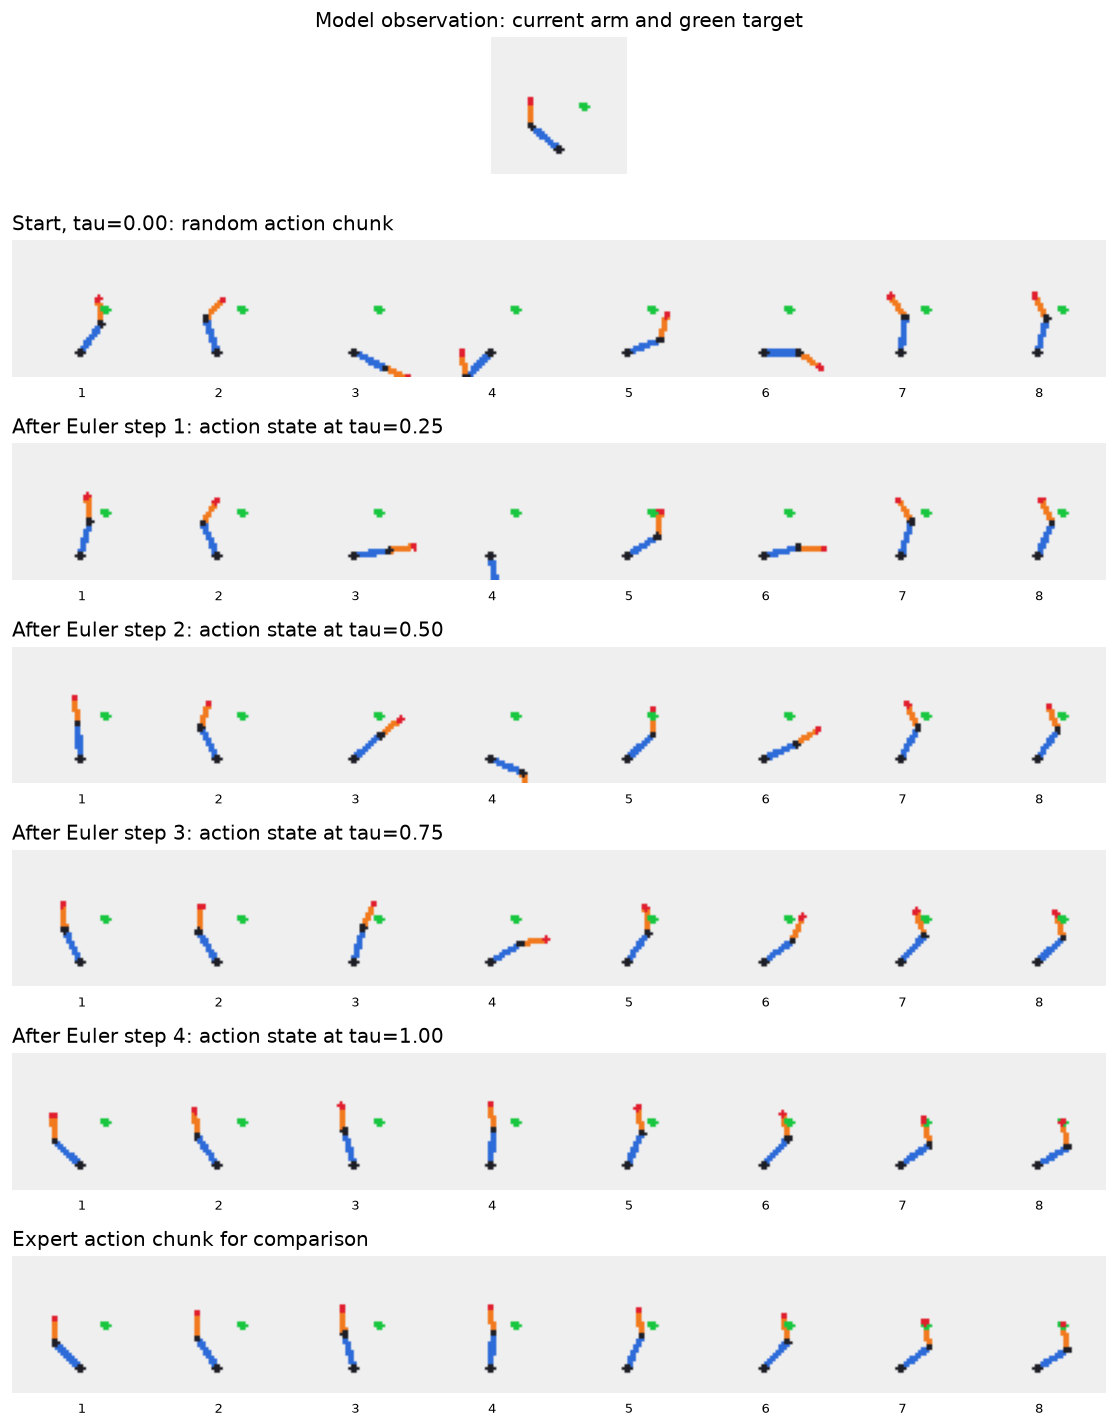

DiT evaluated at tau = [0.0, 0.25, 0.5, 0.75]
final joint-action MSE = 0.0012445560423657298


In [47]:
@torch.no_grad()
def euler_generate_actions(model, rgb_image, current_joints, num_steps=4, initial_noise=None):
    """使用 Euler 数值积分，从随机关节动作生成完整动作 chunk。"""

    # batch size 来自当前关节状态。
    batch_size = current_joints.shape[0]

    # 没有指定初始噪声时，随机初始化 [B,8,2]。
    if initial_noise is None:
        current_actions = torch.randn(
            batch_size, HORIZON, ACTION_DIM, device=current_joints.device
        ) * 1.10
    else:
        # clone 保留调用者的原始噪声。
        current_actions = initial_noise.clone()

    # 保存初始动作和所有中间动作状态。
    action_states = [current_actions.clone()]

    # 保存 DiT 的实际调用时间。
    evaluated_taus = []

    # K 步 Euler 的固定步长是 1/K。
    delta_tau = 1.0 / num_steps

    # 在同一个机器人决策内部多次调用 DiT。
    for step_index in range(num_steps):
        # 第 i 次调用位置是 i/K。
        tau_value = step_index / num_steps

        # 为 batch 创建 [B] tau 张量。
        tau = torch.full((batch_size,), tau_value, device=current_joints.device)

        # 模型根据相同 observation 和当前动作状态预测 velocity。
        predicted_velocity = model(rgb_image, current_joints, current_actions, tau)

        # Euler 更新动作；更新后的动作会在下一轮重新经过 action encoder。
        current_actions = current_actions + delta_tau * predicted_velocity

        # 保存这一步结果用于渲染。
        evaluated_taus.append(tau_value)
        action_states.append(current_actions.clone())

    # 返回最终动作和完整中间状态。
    return current_actions, action_states, evaluated_taus

# 定义一个新的测试场景。
test_current_joints = torch.tensor([[2.45, -0.85]], device=device)
test_target_joints = torch.tensor([[0.55, 1.20]], device=device)

# 目标关节角只用于产生绿色目标和专家比较。
_, test_target_xy = forward_kinematics(test_target_joints)

# 渲染模型实际获得的测试 RGB observation。
test_rgb = render_robot_images(test_current_joints, test_target_xy)

# 专家动作不输入模型，只用于最后对照。
test_expert_actions = make_expert_joint_actions(test_current_joints, test_target_joints)

# 固定初始随机动作，便于重复实验。
torch.manual_seed(23)
test_initial_noise = torch.randn_like(test_expert_actions) * 1.10

# 使用四步 Euler 生成动作。
generated_actions, generated_states, evaluated_taus = euler_generate_actions(
    model, test_rgb, test_current_joints, num_steps=4, initial_noise=test_initial_noise
)

# 第一行显示模型的单张 RGB observation。
fig, axes = plt.subplots(7, 1, figsize=(15, 12))
show_rgb(axes[0], test_rgb[0], 'Model observation: current arm and green target')

# 第二行显示纯随机动作 rollout。
show_rollout_row(axes[1], generated_states[0][0], test_target_xy[0], 'Start, tau=0.00: random action chunk')

# 接下来四行显示每次 Euler 更新后的 8 帧动作。
for step_index in range(4):
    reached_tau = (step_index + 1) / 4
    show_rollout_row(
        axes[step_index + 2],
        generated_states[step_index + 1][0],
        test_target_xy[0],
        f'After Euler step {step_index + 1}: action state at tau={reached_tau:.2f}',
    )

# 最后一行显示专家动作供比较。
show_rollout_row(axes[6], test_expert_actions[0], test_target_xy[0], 'Expert action chunk for comparison')
plt.tight_layout()
plt.show()

# 打印实际 DiT 调用时间和最终关节动作误差。
print('DiT evaluated at tau =', evaluated_taus)
print('final joint-action MSE =', float(F.mse_loss(generated_actions, test_expert_actions)))


## 6. 训练随机 tau，部署固定 tau

训练随机采样 `tau` 是为了让 DiT 学习整个 `[0,1]` 上不同噪声程度的 velocity field。四步部署只是在这个 field 上选四个 Euler 检查点。

训练也可以只从 `{0,0.25,0.5,0.75}` 采样，但这只让时间位置一致。训练中的 `x_tau` 由专家动作直接构造；部署中的中间动作来自模型前一步预测，所以两者仍然不完全相同。


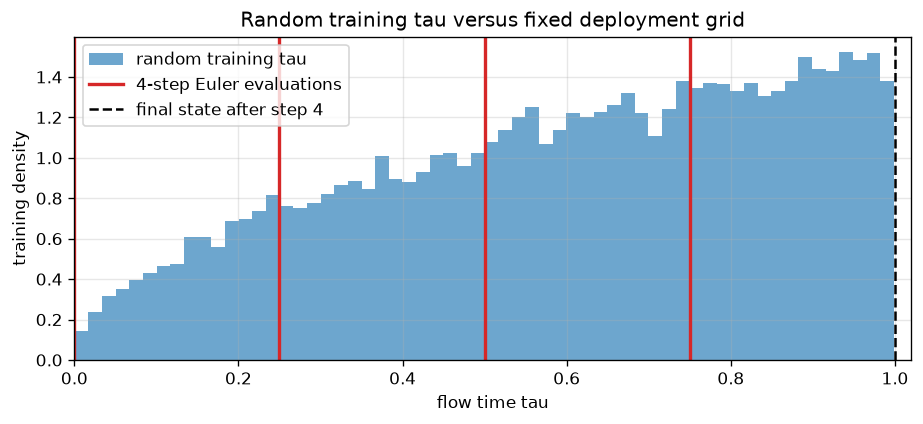

In [45]:
# 在 CPU 上采样大量训练 tau，仅用于画概率分布。
training_taus = 0.999 * torch.distributions.Beta(
    torch.tensor(1.5), torch.tensor(1.0)
).sample((20_000,))

# 四步 Euler 实际调用模型的时间点。
inference_taus = [0.00, 0.25, 0.50, 0.75]

# 绘制随机训练时间分布。
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(training_taus.numpy(), bins=60, density=True, alpha=0.65, label='random training tau')

# 用红线标出固定部署检查点。
for index, tau_value in enumerate(inference_taus):
    ax.axvline(
        tau_value,
        color='tab:red',
        linewidth=2,
        label='4-step Euler evaluations' if index == 0 else None,
    )

# tau=1 是第四次更新后的状态，不是第五次 DiT 调用。
ax.axvline(1.0, color='black', linestyle='--', label='final state after step 4')
ax.set_xlim(0.0, 1.02)
ax.set_xlabel('flow time tau')
ax.set_ylabel('training density')
ax.set_title('Random training tau versus fixed deployment grid')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 7. 自己修改机械臂姿态、目标和 Euler steps

修改下面五个数就能生成新仿真。目标关节角不会输入模型，只用来放置绿色目标点。模型仍然只能依赖 RGB 图像和当前关节状态。


In [ ]:
# 当前机械臂两个关节角，单位是弧度。
CURRENT_SHOULDER = 2.10
CURRENT_ELBOW = 0.55

# 这两个角只用于确定一个可达绿色目标。
TARGET_SHOULDER = 0.95
TARGET_ELBOW = 0.90

# 尝试 1、2、4、8 或 16。
NUMBER_OF_EULER_STEPS = 4

# 将参数变成 batch size 为 1 的张量。
custom_current_joints = torch.tensor(
    [[CURRENT_SHOULDER, CURRENT_ELBOW]], dtype=torch.float32, device=device
)
custom_target_joints = torch.tensor(
    [[TARGET_SHOULDER, TARGET_ELBOW]], dtype=torch.float32, device=device
)

# 通过正运动学生成绿色目标点。
_, custom_target_xy = forward_kinematics(custom_target_joints)

# 渲染模型的 RGB observation。
custom_rgb = render_robot_images(custom_current_joints, custom_target_xy)

# 专家动作只用于最后比较。
custom_expert_actions = make_expert_joint_actions(custom_current_joints, custom_target_joints)

# 固定初始噪声。
torch.manual_seed(123)
custom_noise = torch.randn_like(custom_expert_actions) * 1.10

# 使用指定 Euler 步数生成动作。
custom_actions, custom_states, custom_taus = euler_generate_actions(
    model, custom_rgb, custom_current_joints, NUMBER_OF_EULER_STEPS, custom_noise
)

# observation、初始噪声、每次 Euler 状态和专家动作各占一行。
number_of_rows = NUMBER_OF_EULER_STEPS + 3
fig, axes = plt.subplots(number_of_rows, 1, figsize=(15, 1.65 * number_of_rows))
show_rgb(axes[0], custom_rgb[0], 'Custom RGB observation')
show_rollout_row(axes[1], custom_states[0][0], custom_target_xy[0], 'Initial random action chunk')

# 逐行显示每一次更新后的完整 8 帧 rollout。
for step_index in range(NUMBER_OF_EULER_STEPS):
    show_rollout_row(
        axes[step_index + 2],
        custom_states[step_index + 1][0],
        custom_target_xy[0],
        f'After Euler step {step_index + 1}',
    )

# 最后一行显示专家 rollout。
show_rollout_row(axes[-1], custom_expert_actions[0], custom_target_xy[0], 'Expert rollout')
plt.tight_layout()
plt.show()

# 输出时间网格和最终误差。
print('DiT evaluated at tau =', custom_taus)
print('final joint-action MSE =', float(F.mse_loss(custom_actions, custom_expert_actions)))


## 8. 最终流程

### 训练

```text
RGB 仿真图像 -> CNN -> image context token
当前关节角   -> MLP -> state context token
专家动作 a + 随机动作 epsilon + 随机 tau -> x_tau
x_tau -> action encoder -> action tokens

DiT(action tokens, image/state context, tau) -> velocity
loss = MSE(velocity, a-epsilon)
```

### 部署

```text
current_actions = random joint actions

for tau in [0.00, 0.25, 0.50, 0.75]:
    action_tokens = action_encoder(current_actions)
    velocity = DiT(RGB context, state context, action_tokens, tau)
    current_actions = current_actions + 0.25 * velocity

执行最终 8 步关节动作
```

action encoder 第一次编码随机关节动作，之后每次编码前一轮 Euler 更新后的关节动作。
